In [2]:
import pandas as pd
import os
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('banco_fenotipos_conformal.csv')
df = df.replace(['Não respondeu', 'não respondeu', 'NAO RESPONDEU'], np.nan)

In [4]:
print(len(df))

720


In [5]:
print(df.columns)

Index(['id', 'hb_g_dl', 'glicose_mg_dl', 'samplefilename', 'fumo', 'raca_cor',
       'conjugal3', 'trabalho2', 'bebem2', 'sexo', 'idade', 'faixa_etaria',
       'imc', 'imc_cat4_aferido', 'imc_cat_aferido', 'ep', 'obesidade', 'ccm',
       'obes_central', 'cc_estat', 'cc_estat_cat', 'medDM_bioq', 'diabetes2',
       'HOMA_IR', 'HOMA_cat', 'pas_final', 'pad_final', 'medHAS_bioq', 'has2',
       'col_nao_hdlc_mg_dl', 'colnaohdl_cat', 'CP1', 'CP2', 'CP3', 'CP4',
       'CP5', 'CP6'],
      dtype='str')


In [6]:
CATEGORICAS = ['fumo','raca_cor','conjugal3', 'trabalho2', 'bebem2', 'sexo','faixa_etaria', 'imc_cat4_aferido', 'imc_cat_aferido', 'ep', 'obesidade','obes_central','medDM_bioq', 'diabetes2','HOMA_cat','medHAS_bioq','has2','colnaohdl_cat']

In [7]:
dfcat = df[CATEGORICAS]

In [8]:
dfcat['fumo'].describe()

count       715
unique        3
top       nunca
freq        503
Name: fumo, dtype: object

In [9]:
resultados = []
for i in range(len(CATEGORICAS)):
    column = CATEGORICAS[i]
    for j in range(i+1, len(CATEGORICAS)):
        cat_col = CATEGORICAS[j]
        if cat_col == column:
            continue
        contingency_table = pd.crosstab(df[cat_col], df[column])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        resultados.append({'var1': column, 'var2': cat_col, 'p_valor': p, 'dof': dof, 'chi2': chi2})

In [10]:
df_res = pd.DataFrame(resultados)
df_dependentes = df_res[df_res['p_valor'] < 0.05]

In [11]:
display(df_dependentes)

,var1,var2,p_valor,dof,chi2
1,fumo,conjugal3,3.181657e-13,8,75.950461
2,fumo,trabalho2,1.321859e-17,6,91.733672
3,fumo,bebem2,1.312498e-08,6,47.771620
4,fumo,sexo,3.989835e-04,2,15.653181
5,fumo,faixa_etaria,4.876443e-19,4,92.030342
...,...,...,...,...,...
147,HOMA_cat,medHAS_bioq,3.179409e-09,1,35.070750
148,HOMA_cat,has2,1.333761e-07,1,27.816611
150,medHAS_bioq,has2,2.333358e-59,1,263.975480
151,medHAS_bioq,colnaohdl_cat,5.353132e-03,1,7.756104


# Graficos

In [12]:
# Ajustando sexo

mapeamento = {
    1: 'Masculino',
    2: 'Feminino'
}
dfcat['sexo'] = dfcat['sexo'].map(mapeamento)

In [13]:
def plot_pizza(df, coluna):
    dados_pizza = df[coluna].value_counts()
    cores = sns.color_palette('hls', len(dados_pizza))
    
    plt.figure(figsize=(8, 6))
    plt.pie(dados_pizza, 
            labels=dados_pizza.index, 
            autopct='%1.1f%%',  
            startangle=90,
            colors=cores,            
            shadow=True)             
    
    plt.title(f'Proporção Geral da Variável {coluna.capitalize()}')
    plt.axis('equal')
    plt.show()

In [14]:
def plot_proporcao(df, var1, var2):
    proporcao = pd.crosstab(df[var1], df[var2], normalize='index')
    proporcao.plot(kind='bar', stacked=True, color=sns.color_palette('hls', len(proporcao.columns)))
    
    plt.title(f'Influência de {var1.capitalize()} em {var2.capitalize()} (Proporção)')
    plt.ylabel('Frequência Relativa')
    plt.xlabel(var1.capitalize())
    plt.legend(title=var2.capitalize(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [15]:
def plot_distribuicao(df, var1, var2):
    plt.figure(figsize=(8, 6))
    sns.countplot(x=var1, hue=var2, data=df, palette='hls')
    
    plt.title(f'Influência de {var1.capitalize()} em {var2.capitalize()} (Contagem)')
    plt.ylabel('Contagem')
    plt.xlabel(var1.capitalize())
    plt.legend(title=var2.capitalize(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Fumo

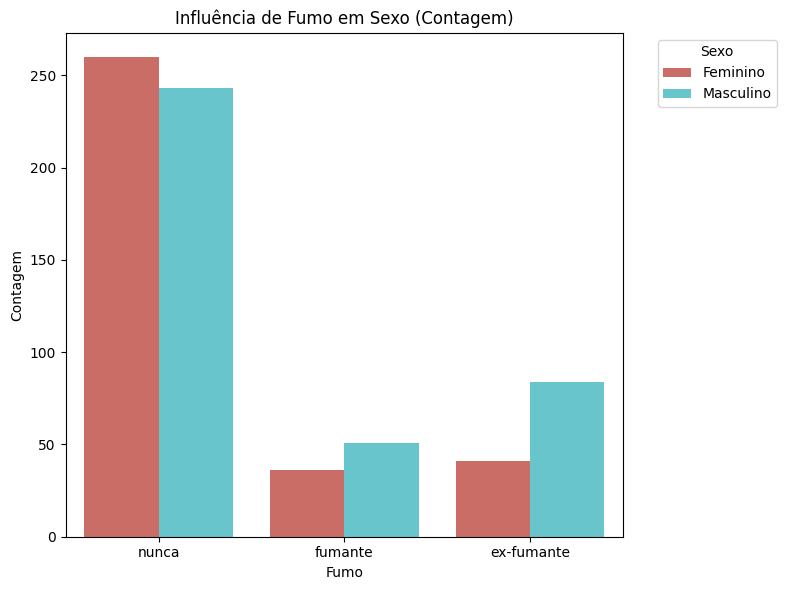

In [16]:
plot_distribuicao(dfcat, 'fumo', 'sexo')

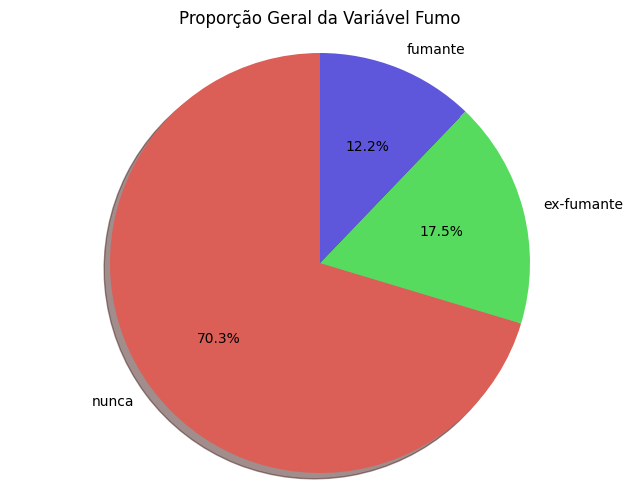

In [17]:
plot_pizza(dfcat, 'fumo')

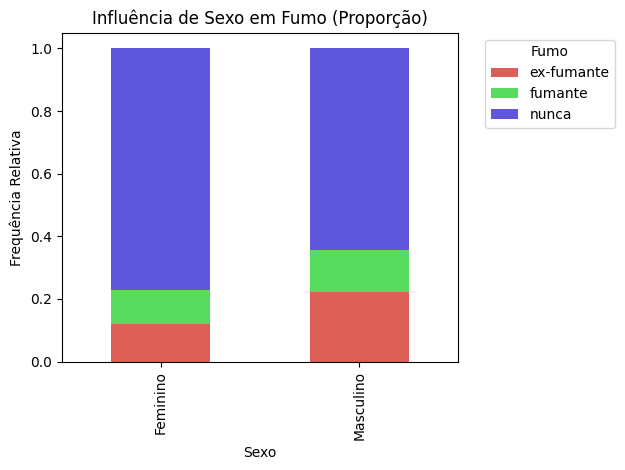

In [18]:
plot_proporcao(dfcat, 'sexo', 'fumo')

## Raca cor

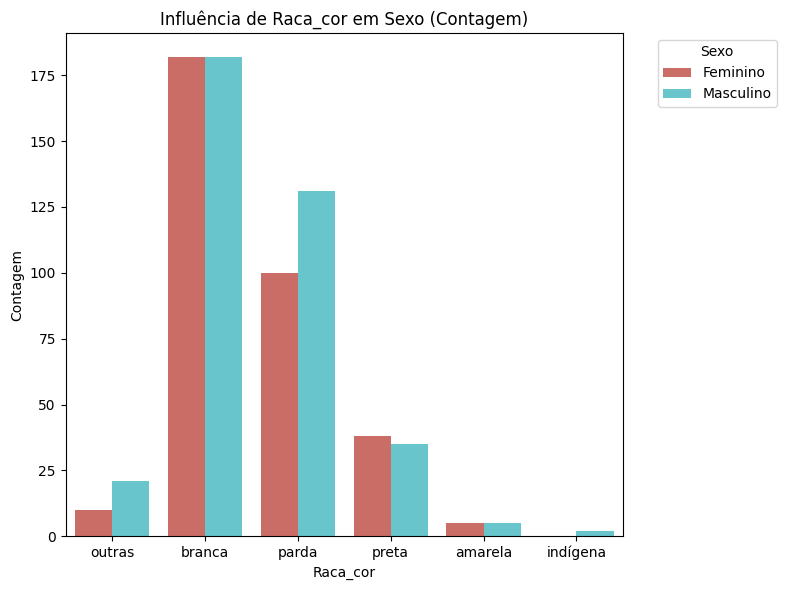

In [19]:
plot_distribuicao(dfcat, 'raca_cor', 'sexo')

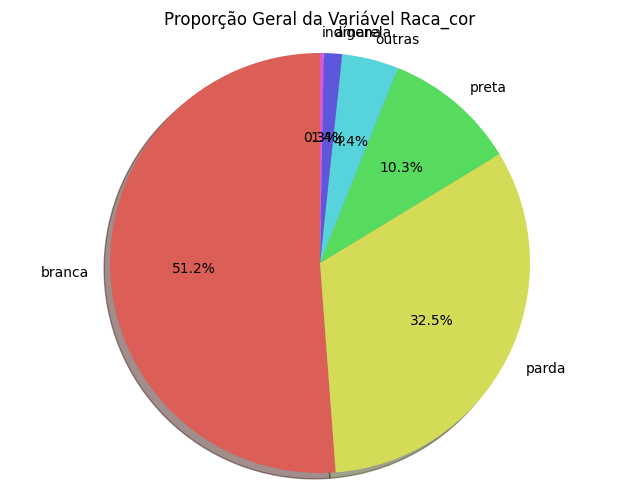

In [20]:
plot_pizza(dfcat, 'raca_cor')

## Faixa Etaria

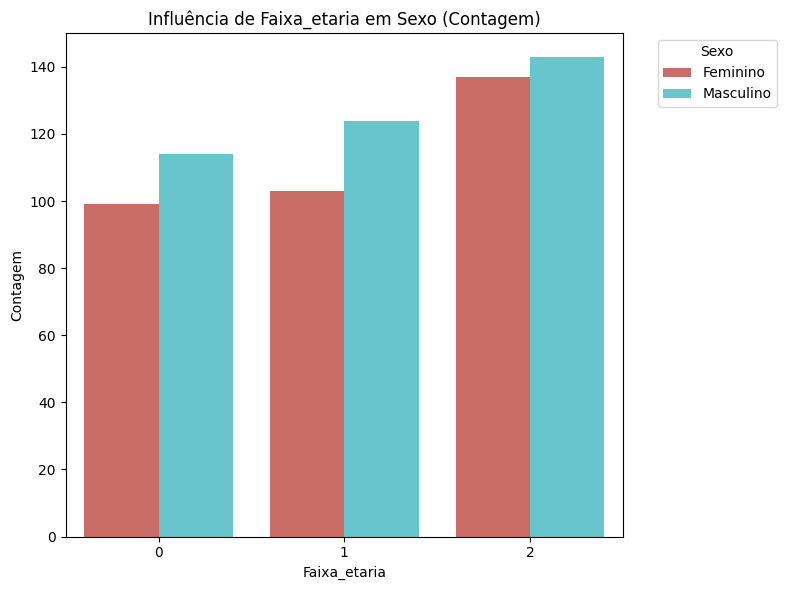

In [ ]:
plot_distribuicao(dfcat, 'faixa_etaria', 'sexo')
# 0=adolescentes (0-19 anos); 1=adultos (20-59 anos); 2=idosos (60 anos ou mais)

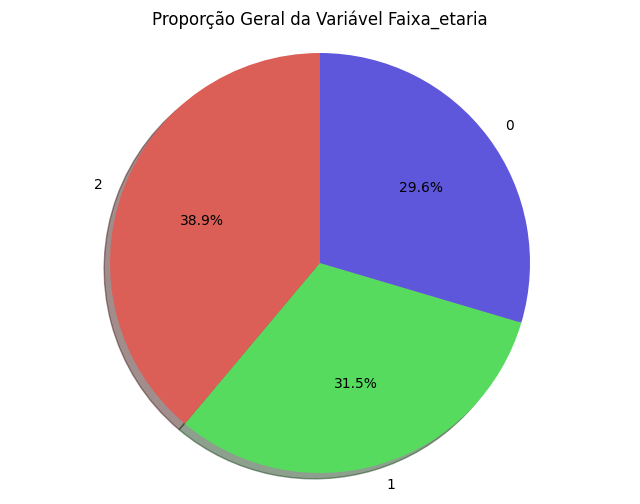

In [ ]:
plot_pizza(dfcat, 'faixa_etaria')
# 0=adolescentes (0-19 anos); 1=adultos (20-59 anos); 2=idosos (60 anos ou mais)